In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


Train Shape: (30000, 24)
Test Shape: (20000, 23)


In [3]:
train_df.head()


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [4]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

In [5]:
TARGET = "Loan Sanction Amount (USD)"


In [6]:
DROP_COLS = ["Customer ID", "Name", "Property ID"]


In [17]:
train_df = train_df.dropna(subset=["Loan Sanction Amount (USD)"])
X_train = train_df.drop(columns=DROP_COLS + [TARGET])
y_train = train_df[TARGET]



In [18]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)


Numeric Features: ['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price']
Categorical Features: ['Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']


In [19]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [21]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


In [22]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
# train_preds = model.predict(X_train)

# print("R² Score:", r2_score(y_train, train_preds))
# print("RMSE:", mean_squared_error(y_train, train_preds, squared=False))
# # 

In [28]:
test_predictions = model.predict(X_test)

test_df["Predicted Loan Sanction Amount (USD)"] = test_predictions
test_df.head()


ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: '?'

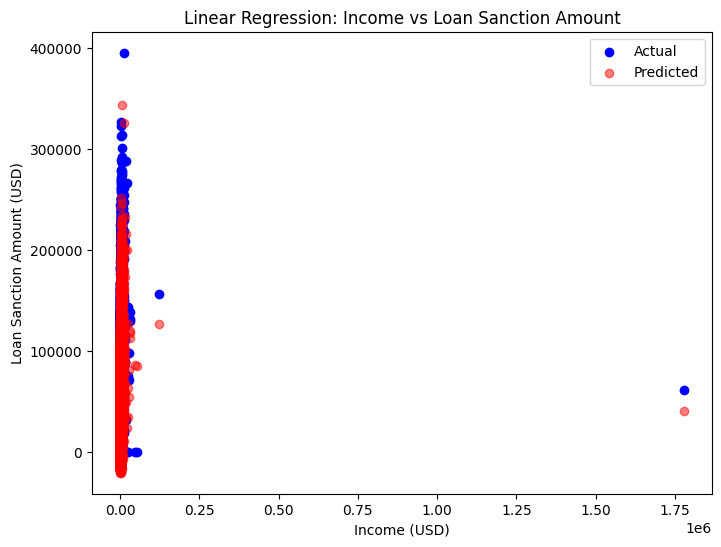

In [29]:
import matplotlib.pyplot as plt

# Choose ONE numeric feature
feature = "Income (USD)"

# Get actual values
X_feature = X_train[feature]
y_actual = y_train

# Predict using trained model
y_pred = model.predict(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_feature, y_actual, color="blue", label="Actual")
plt.scatter(X_feature, y_pred, color="red", label="Predicted", alpha=0.5)

plt.xlabel("Income (USD)")
plt.ylabel("Loan Sanction Amount (USD)")
plt.title("Linear Regression: Income vs Loan Sanction Amount")
plt.legend()
plt.show()


C:\Users\krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  return bound(*args, **kwds)


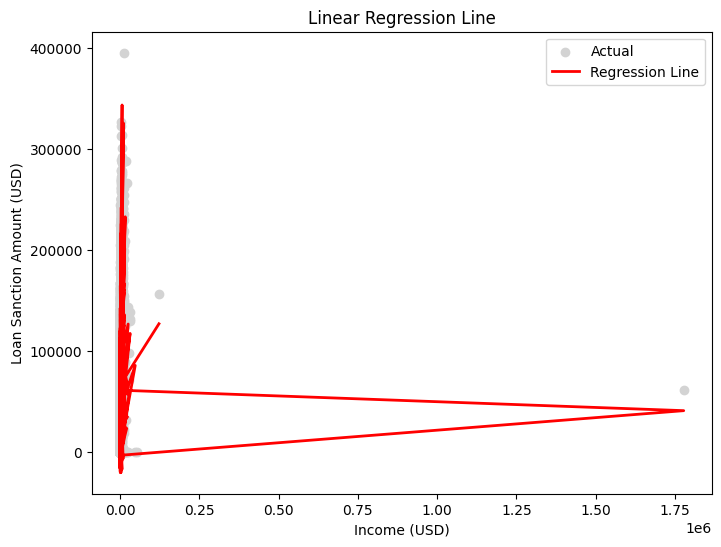

In [31]:
import numpy as np

sorted_idx = np.argsort(X_feature)
X_sorted = X_feature.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(8, 6))
plt.scatter(X_feature, y_actual, color="lightgray", label="Actual")
plt.plot(X_sorted, y_pred_sorted, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Income (USD)")
plt.ylabel("Loan Sanction Amount (USD)")
plt.title("Linear Regression Line")
plt.legend()
plt.show()


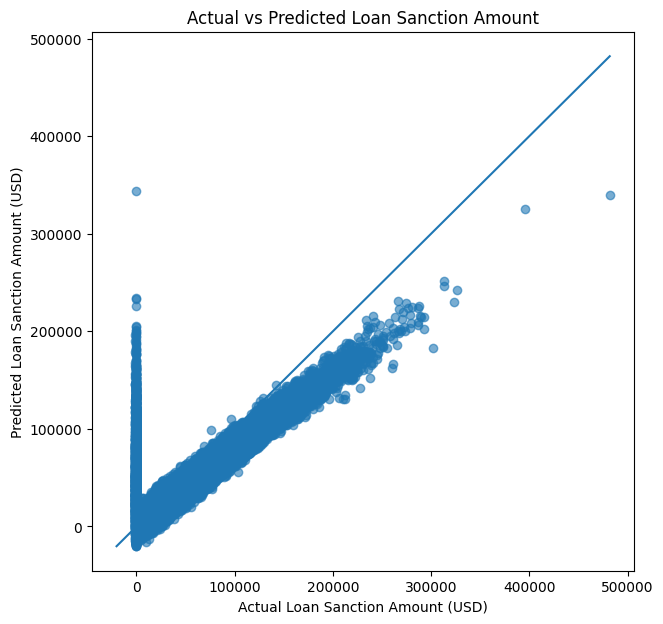

In [32]:
plt.figure(figsize=(7, 7))
plt.scatter(y_train, y_pred, alpha=0.6)

plt.xlabel("Actual Loan Sanction Amount (USD)")
plt.ylabel("Predicted Loan Sanction Amount (USD)")
plt.title("Actual vs Predicted Loan Sanction Amount")

# Ideal prediction line
min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()
